In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('Ventas_por_Asesor_sin_nulos.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0.1         53 non-null     int64  
 1   Unnamed: 0           53 non-null     str    
 2   2024-02-01 00:00:00  53 non-null     float64
 3   2024-03-01 00:00:00  53 non-null     float64
 4   2024-04-01 00:00:00  53 non-null     float64
 5   2024-05-01 00:00:00  53 non-null     float64
 6   2024-06-01 00:00:00  53 non-null     float64
 7   2024-07-01 00:00:00  53 non-null     float64
 8   2024-08-01 00:00:00  53 non-null     float64
 9   2024-09-01 00:00:00  53 non-null     float64
 10  2024-10-01 00:00:00  53 non-null     float64
 11  2024-11-01 00:00:00  53 non-null     float64
 12  2024-12-01 00:00:00  53 non-null     float64
 13  2025-01-01 00:00:00  53 non-null     float64
 14  2025-02-01 00:00:00  53 non-null     float64
 15  2025-03-01 00:00:00  53 non-null     float64
 16  202

In [4]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Unnamed: 0.1           0
Unnamed: 0             0
2024-02-01 00:00:00    0
2024-03-01 00:00:00    0
2024-04-01 00:00:00    0
2024-05-01 00:00:00    0
2024-06-01 00:00:00    0
2024-07-01 00:00:00    0
2024-08-01 00:00:00    0
2024-09-01 00:00:00    0
2024-10-01 00:00:00    0
2024-11-01 00:00:00    0
2024-12-01 00:00:00    0
2025-01-01 00:00:00    0
2025-02-01 00:00:00    0
2025-03-01 00:00:00    0
2025-04-01 00:00:00    0
2025-05-01 00:00:00    0
2025-06-01 00:00:00    0
2025-07-01 00:00:00    0
2025-08-01 00:00:00    0
2025-09-01 00:00:00    0
2025-10-01 00:00:00    0
2025-11-01 00:00:00    0
2025-12-01 00:00:00    0
2026-01-01 00:00:00    0
2026-02-01 00:00:00    0
2026-03-01 00:00:00    0
2026-04-01 00:00:00    0
2026-05-01 00:00:00    0
2026-06-01 00:00:00    0
2026-07-01 00:00:00    0
Unnamed: 31            0
Unnamed: 32            0
2024                   0
Unnamed: 34            0
2025                   0
Unnamed: 36            0
2026                   0
Unnamed: 38            0


In [6]:
#Creo 2 dataframe para poder procesar los outliers
cuantitativas= data.iloc[ : , 2:33 ]
cualitativas = data.iloc[:, [1, 33, 34, 35, 36, 37, 38, 39]]

<Figure size 1500x800 with 0 Axes>

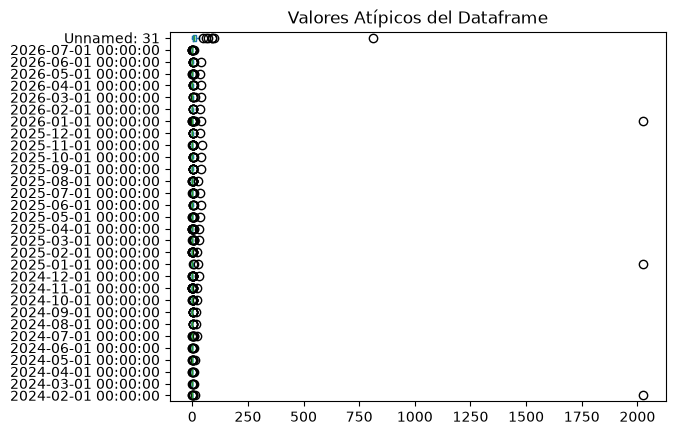

In [7]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [8]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido 2024-02-01 00:00:00    872.522608
2024-03-01 00:00:00      3.440739
2024-04-01 00:00:00      4.003571
2024-05-01 00:00:00      6.303694
2024-06-01 00:00:00      2.963438
2024-07-01 00:00:00     10.285824
2024-08-01 00:00:00      8.201142
2024-09-01 00:00:00      7.968617
2024-10-01 00:00:00     10.625248
2024-11-01 00:00:00     10.146474
2024-12-01 00:00:00     14.667211
2025-01-01 00:00:00    873.315480
2025-02-01 00:00:00      9.217647
2025-03-01 00:00:00     14.209272
2025-04-01 00:00:00     14.076245
2025-05-01 00:00:00     15.996169
2025-06-01 00:00:00     18.363564
2025-07-01 00:00:00     16.588584
2025-08-01 00:00:00     12.465088
2025-09-01 00:00:00     17.335807
2025-10-01 00:00:00     18.322437
2025-11-01 00:00:00     19.229806
2025-12-01 00:00:00     15.602715
2026-01-01 00:00:00    874.096887
2026-02-01 00:00:00     15.554287
2026-03-01 00:00:00     19.124575
2026-04-01 00:00:00     18.956379
2026-05-01 00:00:00     16.213916
2026-06-01 00:00:00   

In [9]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data2= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data2

,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,...,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00,2026-07-01 00:00:00,Unnamed: 31
0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,0.0,0.0,1.0,2.0,0.0,7.0,2.0,3.0,3.0,1.0,...,3.0,1.0,6.0,2.0,2.0,5.0,2.0,4.0,0.0,88.0
2,0.0,0.0,0.0,0.0,1.0,1.0,3.0,0.0,2.0,1.0,...,4.0,4.0,5.0,5.0,4.0,2.0,5.0,3.0,2.0,88.0
3,0.0,0.0,0.0,1.0,2.0,7.0,5.0,2.0,2.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0
4,1.0,0.0,0.0,2.0,0.0,0.0,0.0,3.0,2.0,1.0,...,3.0,4.0,11.0,4.0,12.0,10.0,6.0,9.0,1.0,98.0
5,0.0,2.0,3.0,5.0,2.0,3.0,3.0,3.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,2.0,2.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,46.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,5.0,4.0,3.0,5.0,1.0,6.0,3.0,3.0,72.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,5.0,3.0,1.0,5.0,3.0,3.0,1.0,1.0,1.0,63.0
9,0.0,0.0,0.0,0.0,0.0,2.0,4.0,2.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0


In [10]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data2.isnull().sum()
valores_nulos

2024-02-01 00:00:00    1
2024-03-01 00:00:00    1
2024-04-01 00:00:00    1
2024-05-01 00:00:00    1
2024-06-01 00:00:00    1
2024-07-01 00:00:00    1
2024-08-01 00:00:00    1
2024-09-01 00:00:00    1
2024-10-01 00:00:00    1
2024-11-01 00:00:00    1
2024-12-01 00:00:00    1
2025-01-01 00:00:00    1
2025-02-01 00:00:00    1
2025-03-01 00:00:00    1
2025-04-01 00:00:00    1
2025-05-01 00:00:00    1
2025-06-01 00:00:00    1
2025-07-01 00:00:00    1
2025-08-01 00:00:00    1
2025-09-01 00:00:00    1
2025-10-01 00:00:00    1
2025-11-01 00:00:00    1
2025-12-01 00:00:00    1
2026-01-01 00:00:00    1
2026-02-01 00:00:00    1
2026-03-01 00:00:00    1
2026-04-01 00:00:00    1
2026-05-01 00:00:00    1
2026-06-01 00:00:00    1
2026-07-01 00:00:00    1
Unnamed: 31            1
dtype: int64

In [11]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data2.copy()
data_clean=data_clean.fillna(round(data2.mean(),1))
data_clean

,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,...,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00,2026-07-01 00:00:00,Unnamed: 31
0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,15.6
1,0.0,0.0,1.0,2.0,0.0,7.0,2.0,3.0,3.0,1.0,...,3.0,1.0,6.0,2.0,2.0,5.0,2.0,4.0,0.0,88.0
2,0.0,0.0,0.0,0.0,1.0,1.0,3.0,0.0,2.0,1.0,...,4.0,4.0,5.0,5.0,4.0,2.0,5.0,3.0,2.0,88.0
3,0.0,0.0,0.0,1.0,2.0,7.0,5.0,2.0,2.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0
4,1.0,0.0,0.0,2.0,0.0,0.0,0.0,3.0,2.0,1.0,...,3.0,4.0,11.0,4.0,12.0,10.0,6.0,9.0,1.0,98.0
5,0.0,2.0,3.0,5.0,2.0,3.0,3.0,3.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,2.0,2.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,46.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,5.0,4.0,3.0,5.0,1.0,6.0,3.0,3.0,72.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,5.0,3.0,1.0,5.0,3.0,3.0,1.0,1.0,1.0,63.0
9,0.0,0.0,0.0,0.0,0.0,2.0,4.0,2.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0


In [12]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

2024-02-01 00:00:00    0
2024-03-01 00:00:00    0
2024-04-01 00:00:00    0
2024-05-01 00:00:00    0
2024-06-01 00:00:00    0
2024-07-01 00:00:00    0
2024-08-01 00:00:00    0
2024-09-01 00:00:00    0
2024-10-01 00:00:00    0
2024-11-01 00:00:00    0
2024-12-01 00:00:00    0
2025-01-01 00:00:00    0
2025-02-01 00:00:00    0
2025-03-01 00:00:00    0
2025-04-01 00:00:00    0
2025-05-01 00:00:00    0
2025-06-01 00:00:00    0
2025-07-01 00:00:00    0
2025-08-01 00:00:00    0
2025-09-01 00:00:00    0
2025-10-01 00:00:00    0
2025-11-01 00:00:00    0
2025-12-01 00:00:00    0
2026-01-01 00:00:00    0
2026-02-01 00:00:00    0
2026-03-01 00:00:00    0
2026-04-01 00:00:00    0
2026-05-01 00:00:00    0
2026-06-01 00:00:00    0
2026-07-01 00:00:00    0
Unnamed: 31            0
dtype: int64

In [13]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data_clean], axis=1)
Datos_limpios

,Unnamed: 0,Unnamed: 32,2024,Unnamed: 34,2025,Unnamed: 36,2026,Unnamed: 38,2024-02-01 00:00:00,2024-03-01 00:00:00,...,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00,2026-07-01 00:00:00,Unnamed: 31
0,Nombre vendedor,Raking,Acum,Ranking,Acum,Ranking,Acum,Ranking,0.5,0.0,...,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,15.6
1,PEDRO GONZALEZ ESPINDOLA,0,22,0,45,3,21,0,0.0,0.0,...,3.0,1.0,6.0,2.0,2.0,5.0,2.0,4.0,0.0,88.0
2,VICTOR MANUEL SANCHEZ ARRO,0,11,0,51,0,26,0,0.0,0.0,...,4.0,4.0,5.0,5.0,4.0,2.0,5.0,3.0,2.0,88.0
3,MIGUEL ANGEL SONDEREGGER,6,27,2,1,26,0,18,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0
4,JOSE ANTONIO LICONA MENDE,1,10,5,35,5,53,2,1.0,0.0,...,3.0,4.0,11.0,4.0,12.0,10.0,6.0,9.0,1.0,98.0
5,JAIME GONZALEZ CORONA,8,25,3,0,31,0,18,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0
6,ALAN GONZÁLEZ BELANZATEGU,4,4,11,36,4,6,12,0.0,0.0,...,2.0,2.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,46.0
7,MAURICIO ALFREDO VAZQUEZ F,2,0,25,47,2,25,3,0.0,0.0,...,5.0,5.0,4.0,3.0,5.0,1.0,6.0,3.0,3.0,72.0
8,AURELIO FELIPE TORRES REV,3,3,13,45,3,15,4,0.0,0.0,...,5.0,3.0,1.0,5.0,3.0,3.0,1.0,1.0,1.0,63.0
9,J4OSETTE RAMON NAVA FLORES,11,16,4,0,31,0,18,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.0


In [14]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Unnamed: 0             0
Unnamed: 32            0
2024                   0
Unnamed: 34            0
2025                   0
Unnamed: 36            0
2026                   0
Unnamed: 38            0
2024-02-01 00:00:00    0
2024-03-01 00:00:00    0
2024-04-01 00:00:00    0
2024-05-01 00:00:00    0
2024-06-01 00:00:00    0
2024-07-01 00:00:00    0
2024-08-01 00:00:00    0
2024-09-01 00:00:00    0
2024-10-01 00:00:00    0
2024-11-01 00:00:00    0
2024-12-01 00:00:00    0
2025-01-01 00:00:00    0
2025-02-01 00:00:00    0
2025-03-01 00:00:00    0
2025-04-01 00:00:00    0
2025-05-01 00:00:00    0
2025-06-01 00:00:00    0
2025-07-01 00:00:00    0
2025-08-01 00:00:00    0
2025-09-01 00:00:00    0
2025-10-01 00:00:00    0
2025-11-01 00:00:00    0
2025-12-01 00:00:00    0
2026-01-01 00:00:00    0
2026-02-01 00:00:00    0
2026-03-01 00:00:00    0
2026-04-01 00:00:00    0
2026-05-01 00:00:00    0
2026-06-01 00:00:00    0
2026-07-01 00:00:00    0
Unnamed: 31            0
dtype: int64

In [15]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Ventas_por_Asesor_sin_valores_atipicos.csv")